In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 🏷️ Seaborn Categorical Data Plots: Complete Roadmap

This suite analyzes distributions, frequencies, and statistical estimates across distinct groups or categorical classifications.

---

### 🗺️ Categorical Plot Types Reference

| Category | Plot Function | Quick Description | Best Used For... |
| :--- | :--- | :--- | :--- |
| **1. Categorical Scatter** | `sns.stripplot()` | Plots individual data points with optional random jitter. | Small datasets, raw distributions |
| | `sns.swarmplot()` | Shifts overlapping points sideways to show density shape. | Medium datasets, exact data mapping |
| **2. Categorical Distribution** | `sns.boxplot()` | Shows median, quartiles, and explicit outliers via whiskers. | Spotting anomalies, rapid summaries |
| | `sns.violinplot()` | Combines box plot metrics with a smooth density curve. | Tracking multi-modal distributions |
| | `sns.boxenplot()` | Letter-value plot showing finer, deeper quantile steps. | Large datasets (>10,000 rows) |
| **3. Estimate & Frequency** | `sns.barplot()` | Uses bars to show central estimates (usually the average). | Executive summaries, mean comparisons |
| | `sns.countplot()` | Simple frequency histogram that counts row occurrences. | Distribution of category sizes |
| | `sns.pointplot()` | Connects average estimates and tracks confidence gaps. | Showing trends or interactions across groups |

---

### 🌐 Global Figure-Level API

```python
sns.catplot(data=df, x="category", y="value", kind="...")
```
* **`catplot()`** is the master figure-level wrapper. 
* Change the **`kind`** parameter (e.g., `kind="box"`, `kind="violin"`, `kind="bar"`) to toggle between any of the 8 plot types listed above.
* Automatically handles subplots and grid layouts using `row` and `col` variables.


In [2]:
df = sns.load_dataset('tips')
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


**Count Plot**

<Axes: xlabel='count', ylabel='sex'>

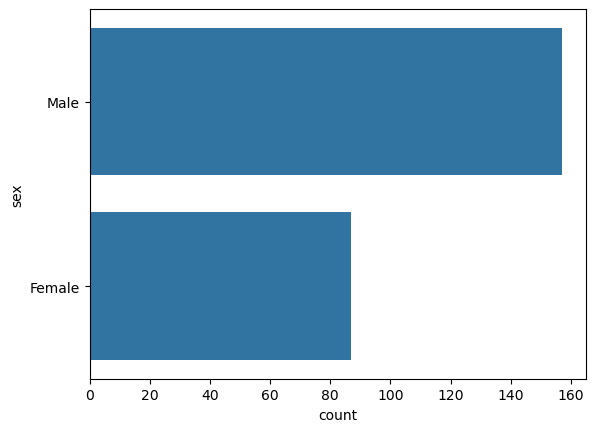

In [3]:
sns.countplot(df['sex'])

<Axes: xlabel='sex', ylabel='count'>

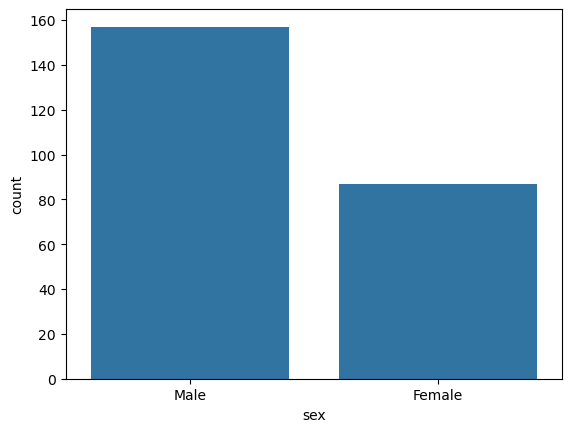

In [4]:
sns.countplot(x = df['sex'])

# 📊 Seaborn Countplot: Quick Revision Reference

```python
sns.countplot(
    data=None, x=None, y=None, hue=None, order=None, hue_order=None, 
    palette=None, stat='count', ax=None
)
```

---

### 🔍 Parameter Cheat Sheet

| Parameter | Type / Default | Quick Action |
| :--- | :--- | :--- |
| **`data`** | DataFrame | The source dataset containing your variables. |
| **`x`** | String label | Maps category to horizontal axis; generates **vertical** bars. |
| **`y`** | String label | Maps category to vertical axis; generates **horizontal** bars. |
| **`hue`** | String label | Splits bars into side-by-side sub-groups using a second category. |
| **`order`** | List of strings | Forces a specific left-to-right sorting order for main categories. |
| **`hue_order`** | List of strings | Controls the order of the sub-groups and legend items. |
| **`palette`** | String \| List | Changes the color scheme (e.g., `"deep"`, `"pastel"`, `"muted"`). |
| **`stat`** | `'count'` | Metric to show. Options: `'count'`, `'percent'`, `'proportion'`, `'probability'`. |
| **`ax`** | Matplotlib Axis | Dictates which subplot grid slot to draw the graphic inside. |

---

### 💡 10-Second Recall Checklist
* **Crucial Rule:** Define either `x` OR `y`, but **never both**. 
* **Horizontal Layout?** Pass your categorical column name to `y` instead of `x`.
* **Pro-tip Ordering:** Sort bars from highest to lowest automatically using: `order=df['column'].value_counts().index`.


<Axes: xlabel='sex', ylabel='count'>

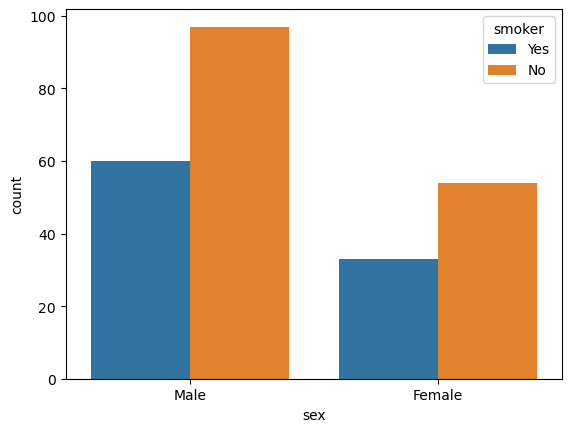

In [5]:
sns.countplot(x = df['sex'], hue = df['smoker'])

**Bar Plot**

# 📊 Seaborn Barplot: Quick Revision Reference

```python
sns.barplot(
    data=None, x=None, y=None, hue=None, estimator='mean', errorbar='ci', 
    order=None, hue_order=None, palette=None, orient=None, ax=None
)
```

---

### 🔍 Parameter Cheat Sheet

| Parameter | Type / Default | Quick Action |
| :--- | :--- | :--- |
| **`data`** | DataFrame | The source dataset containing your variables. |
| **`x`, `y`** | String label | Coordinate mappings; splits your numeric and categorical dimensions. |
| **`hue`** | String label | Splits bars into side-by-side sub-groups using a second category. |
| **`estimator`** | `'mean'` | Statistical operation determining bar height (e.g., `'mean'`, `'median'`, `'sum'`). |
| **`errorbar`** | `'ci'` | Uncertainty line style. Use `'ci'` (Confidence Interval) or `'sd'` (Standard Deviation). |
| **`order`** | List of strings | Forces a specific left-to-right sorting order for main categories. |
| **`hue_order`** | List of strings | Controls the order of the sub-groups and legend items. |
| **`palette`** | String \| List | Changes the color scheme (e.g., `"muted"`, `"dark"`, `"viridis"`). |
| **`orient`** | `'v'` \| `'h'` | Sets explicit direction (**Vertical** vs **Horizontal**). |
| **`ax`** | Matplotlib Axis | Dictates which subplot grid slot to draw the graphic inside. |

---

### 💡 10-Second Recall Checklist
* **What it plots:** By default, it plots the **average (mean)** value of a group, NOT raw totals or individual points.
* **Remove Error Bars?** If the thin lines at the top of your bars clutter your plot, hide them entirely by passing `errorbar=None`.
* **Change from Mean to Sum?** Pass an alternative estimator function directly: `estimator='sum'` or `estimator='median'`.

<Axes: xlabel='sex', ylabel='tip'>

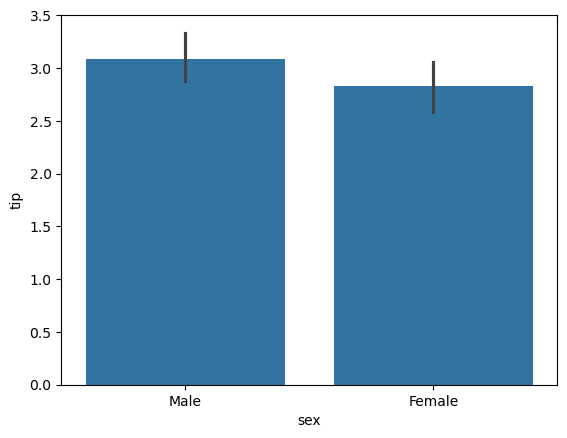

In [6]:
sns.barplot(x = df['sex'], y = df['tip'])

<Axes: xlabel='sex', ylabel='tip'>

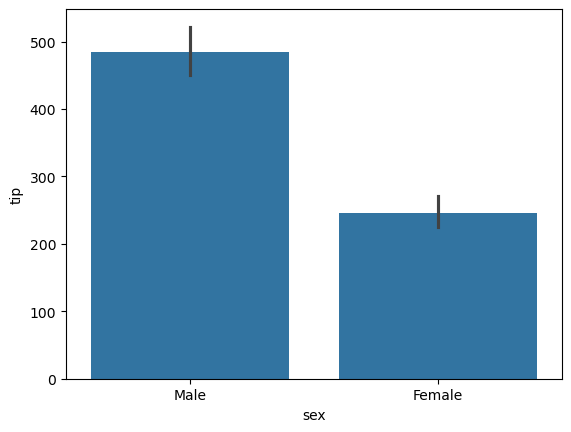

In [7]:
sns.barplot(x = df['sex'], y = df['tip'], estimator=np.sum)

**Box Plot (Crucial)**

# 📊 Seaborn Boxplot: Quick Revision Reference

```python
sns.boxplot(
    data=None, x=None, y=None, hue=None, order=None, hue_order=None, 
    orient=None, palette=None, fill=True, gap=0, whis=1.5, fliersize=5, 
    linewidth=None, ax=None
)
```

---

### 🔍 Parameter Cheat Sheet

| Parameter | Type / Default | Quick Action |
| :--- | :--- | :--- |
| **`data`** | DataFrame | The source dataset containing your variables. |
| **`x`, `y`** | String label | Coordinate mappings; splits numeric and categorical data. |
| **`hue`** | String label | Splits bars into side-by-side sub-groups using a second category. |
| **`order`** | List of strings | Forces a specific left-to-right sorting order for main categories. |
| **`hue_order`** | List of strings | Controls the order of the sub-groups and legend items. |
| **`orient`** | `'v'` \| `'h'` | Sets explicit direction (**Vertical** vs **Horizontal**). |
| **`palette`** | String \| List | Changes the color scheme (e.g., `"Set2"`, `"pastel"`, `"muted"`). |
| **`fill`** | `True` \| `False` | Set to `False` to remove background colors for a clean outline look. |
| **`gap`** | Float (`0` to `1`) | Adds physical spacing between grouped hue boxes (try `0.1`). |
| **`whis`** | Float (Default: `1.5`) | Multiplier for outlier boundaries ($Whisker = \text{Q} \pm \text{whis} \times \text{IQR}$). |
| **`fliersize`** | Int (Default: `5`) | Changes the size of outlier dots. Set to `0` to hide outliers. |
| **`linewidth`** | Float | Adjusts the thickness of the box frames and whisker lines. |
| **`ax`** | Matplotlib Axis | Dictates which subplot grid slot to draw the graphic inside. |

---

### 💡 10-Second Recall Checklist
* **Horizontal Boxplot?** Swap your `x` and `y` mappings (put the numeric column on `x`), or pass `orient="h"`.
* **Cluttered Hues?** Add `gap=0.1` to separate grouped bars cleanly.
* **Hide Outliers?** Pass `fliersize=0`.


<Axes: xlabel='day', ylabel='tip'>

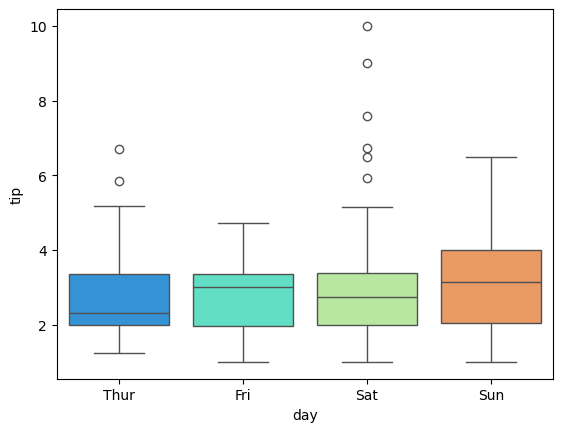

In [8]:
sns.boxplot(data=df, x='day', y='tip', hue='day', palette='rainbow')

## 📊 Box Plots and Violin Plots

Box plots and violin plots visualize the distribution of continuous data across different categorical groups.

### 🔹 Box Plots (Box-and-Whisker)
A box plot shows quantitative data distributions to facilitate quick comparisons across categories. 

* **The Box**: Represents the interquartile range (IQR), highlighting the middle 50% of the dataset and the median line.
* **The Whiskers**: Extend outwards to show the rest of the distribution range.
* **Outliers**: Isolated individual points plotted past the whiskers, calculated as a function of the IQR (typically $1.5 \times \text{IQR}$).

### 🔹 Violin Plots
A violin plot features a symmetric kernel density estimate (KDE) curve on each side. It combines the summary statistics of a box plot with a smoothed view of the data's underlying density shape.

# 🎻 Seaborn Violin Plot: Quick Revision Reference

A violin plot plays a dual role: it combines a traditional box plot with a symmetric kernel density estimate (KDE) curve. This allows you to simultaneously observe summary statistics (like the median) and the underlying distribution shape (such as bimodal peaks).

```python
sns.violinplot(
    data=None, x=None, y=None, hue=None, order=None, hue_order=None,
    bw_adjust=1, cut=2, scale='area', scale_hue=True, gridsize=100,
    width=0.8, inner='box', split=False, dodge=True, orient=None,
    linewidth=None, color=None, palette=None, ax=None
)
```

---

### 🔍 Parameter Cheat Sheet

| Parameter | Type / Default | Quick Action |
| :--- | :--- | :--- |
| **`data`** | DataFrame | The source dataset containing your variables. |
| **`x`, `y`** | String label | Coordinate mappings; splits numeric and categorical data. |
| **`hue`** | String label | Splits the violins into side-by-side sub-groups using a second category. |
| **`split`** | `False` \| `True` | When `hue` is used, setting to `True` draws half-violins side-by-side. |
| **`inner`** | `'box'` | Inside representation. Options: `'box'`, `'quart' (lines)`, `'point'`, `'stick'`, `None`. |
| **`bw_adjust`** | Float (`1.0`) | Adjusts KDE smoothing. Values `< 1` make it sharp; values `> 1` smooth it out. |
| **`cut`** | Float (`2`) | Extends the violin tails past extreme data points (set to `0` to limit to data bounds). |
| **`density_norm`** | `'area'` | Normalizes violin width. Options: `'area'` (equal areas), `'count'` (scales by sample size). |
| **`order`** | List of strings | Forces a specific left-to-right sorting order for main categories. |
| **`palette`** | String \| List | Changes the color scheme (e.g., `"muted"`, `"magma"`, `"Set3"`). |
| **`orient`** | `'v'` \| `'h'` | Sets explicit direction (**Vertical** vs **Horizontal**). |
| **`ax`** | Matplotlib Axis | Dictates which subplot grid slot to draw the graphic inside. |

---

### 💡 10-Second Recall Checklist
* **Split Violins:** When comparing exactly two categories (e.g., Male vs Female), always set `hue="sex"` and `split=True` to save space and compare distributions directly on a single violin.
* **Show Quartiles Clearer:** Change `inner="box"` to `inner="quartile"` to map the 25th, 50th, and 75th percentiles as dashed interior lines.
* **Avoid Flat Tails:** If your data has strict limits (like bills or tips that cannot go below \$0), set `cut=0` to keep the KDE curve from drawing impossible negative values.


<Axes: xlabel='day', ylabel='total_bill'>

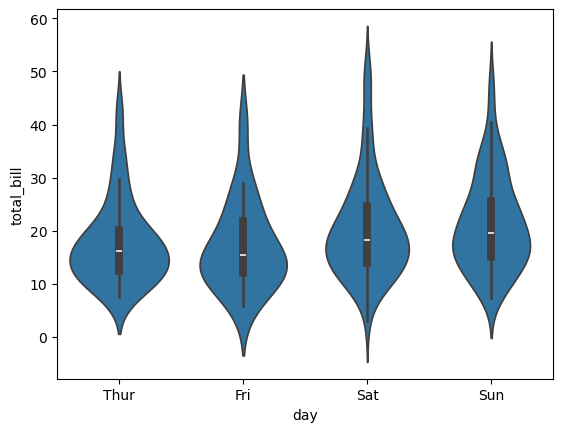

In [9]:
sns.violinplot(x='day', y='total_bill', data=df)

## 📍 Strip Plots and Swarm Plots

Strip plots and swarm plots are categorical scatter plots used to display individual data observations directly.

### 🔹 Strip Plots (`sns.stripplot`)
A strip plot draws a scatter plot where one axis is categorical. 

* **Standalone or Combined**: While it can be drawn on its own, it serves as an excellent complement over a box or violin plot.
* **Granular View**: Overlaying a strip plot allows you to see every single raw observation alongside summarized distribution metrics (like quartiles or density shapes).

### 🔹 Swarm Plots (`sns.swarmplot`)
A swarm plot is highly similar to a strip plot, but the data points are automatically shifted along the categorical axis so that they do not overlap.

* **True Density Representation**: By preventing overlapping data points, it gives a clear visual representation of the true distribution shape.
* **Scale Limitation**: It does not scale well to large numbers of observations. With too much data, points run out of space to expand horizontally, and the computation required to arrange non-overlapping points slows down significantly.


# 📍 Seaborn Strip Plot: Quick Revision Reference

A strip plot is a categorical scatter plot. It displays every single individual observation as a dot along a continuous scale, split by categorical groups. It acts as an excellent underlay or overlay for box and violin plots to reveal the raw data density.

```python
sns.stripplot(
    data=None, x=None, y=None, hue=None, order=None, hue_order=None,
    jitter=True, dodge=False, orient=None, color=None, palette=None,
    size=5, edgecolor='gray', linewidth=0, alpha=1.0, ax=None
)
```

---

### 🔍 Parameter Cheat Sheet

| Parameter | Type / Default | Quick Action |
| :--- | :--- | :--- |
| **`data`** | DataFrame | The source dataset containing your variables. |
| **`x`, `y`** | String label | Coordinate mappings; splits numeric and categorical variables. |
| **`hue`** | String label | Groups and color-codes points using a secondary categorical variable. |
| **`jitter`** | `True` \| Float | Controls random displacement along the categorical axis to reveal overlapping points. |
| **`dodge`** | `False` \| `True` | Separates different `hue` groups into isolated parallel strips. |
| **`size`** | Float (`5`) | Diameter of the marker points in points. |
| **`alpha`** | Float (`1.0`) | Opacity of the points (`0.0` transparent to `1.0` opaque). Helpful for heavy overlaps. |
| **`order`**| List of strings | Forces a specific left-to-right sorting order for main categories. |
| **`palette`**| String \| List | Sets the color scheme for categories or hue markers (e.g., `"vlag"`, `"rocket"`). |
| **`linewidth`**| Float (`0`) | Thickness of the outline boundary drawn around each individual point marker. |
| **`edgecolor`**| Color code | Color of the marker outline (only visible if `linewidth > 0`). |
| **`orient`** | `'v'` \| `'h'` | Sets explicit direction (**Vertical** vs **Horizontal**). |
| **`ax`** | Matplotlib Axis | Dictates which subplot grid slot to draw the graphic inside. |

---

### 💡 10-Second Recall Checklist
* **Manage Heavy Overlaps:** If your data points stack into an unreadable solid block, tune down the opacity using `alpha=0.5` and reduce marker dimensions using `size=3`.
* **Separate Your Hues:** If your `hue` points blend together inside a category, set `dodge=True` to separate them into distinct, clean parallel strips.
* **Fine-Tune Scatter Spread:** Pass a float value to jitter (e.g., `jitter=0.1`) to expand or contract the width of the point scattering field.



# 🐝 Seaborn Swarm Plot: Quick Revision Reference

A swarm plot (sometimes called a "beeswarm") is a categorical scatter plot where points are adjusted automatically along the categorical axis so that they do not overlap. This preserves the visibility of individual data points while revealing the organic distribution shape.

```python
sns.swarmplot(
    data=None, x=None, y=None, hue=None, order=None, hue_order=None,
    dodge=False, orient=None, color=None, palette=None, size=5,
    warn_thresh=0.05, linewidth=0, edgecolor='gray', alpha=1.0, ax=None
)
```

---

### 🔍 Parameter Cheat Sheet

| Parameter | Type / Default | Quick Action |
| :--- | :--- | :--- |
| **`data`** | DataFrame | The source dataset containing your variables. |
| **`x`, `y`** | String label | Coordinate mappings; splits numeric and categorical variables. |
| **`hue`** | String label | Groups and color-codes points using a secondary categorical variable. |
| **`dodge`** | `False` \| `True` | Separates different `hue` groups into isolated, parallel beeswarms. |
| **`size`** | Float (`5`) | Diameter of the marker points. Smaller values fit more points without overlap. |
| **`warn_thresh`**| Float (`0.05`) | Set threshold for triggering warnings when points cannot fit without overlapping. |
| **`alpha`** | Float (`1.0`) | Opacity of the points (`0.0` transparent to `1.0` opaque). |
| **`order`**| List of strings | Forces a specific left-to-right sorting order for main categories. |
| **`palette`**| String \| List | Sets the color scheme for categories or hue markers (e.g., `"deep"`, `"coolwarm"`). |
| **`linewidth`**| Float (`0`) | Thickness of the outline boundary drawn around each individual point marker. |
| **`edgecolor`**| Color code | Color of the marker outline (only visible if `linewidth > 0`). |
| **`orient`** | `'v'` \| `'h'` | Sets explicit direction (**Vertical** vs **Horizontal**). |
| **`ax`** | Matplotlib Axis | Dictates which subplot grid slot to draw the graphic inside. |

---

### 💡 10-Second Recall Checklist
* **Got Spilling Points?** If you see data points spilling off the edges or overlapping wildly, reduce the marker size (e.g., `size=3` or `size=4`).
* **Clean Grouping:** When using a `hue` variable, set `dodge=True` to prevent the distinct categories from tangling together in the same swarm tree.
* **The Scale Warning:** If your dataset contains more than a few hundred rows, avoid `swarmplot`—the layout math will slow your notebook down and turn the plot into a messy block. Use `stripplot` instead.


<Axes: xlabel='day', ylabel='total_bill'>

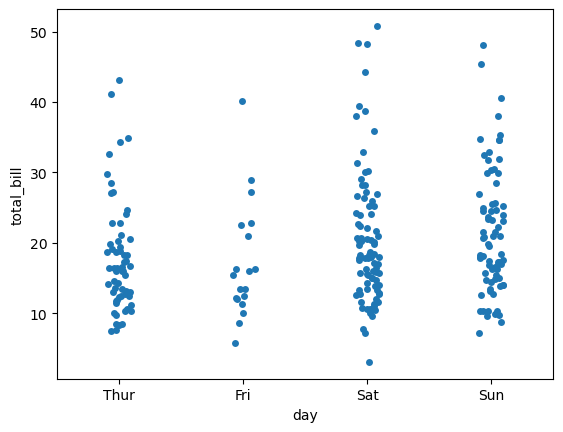

In [10]:
sns.stripplot(x='day', y='total_bill', data=df)

<Axes: xlabel='day', ylabel='total_bill'>

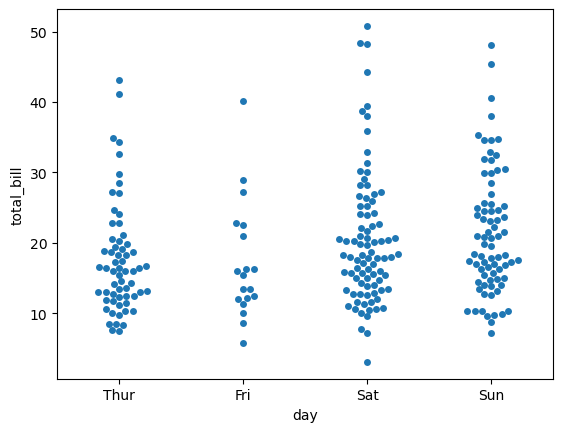

In [11]:
sns.swarmplot(x='day', y='total_bill', data=df)

**Violinplot and Swarmplot in same canvas**

C:\Users\Digital Outlet\AppData\Local\Temp\ipykernel_28636\1296686187.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='tip', y='day', palette='pastel', inner=None)


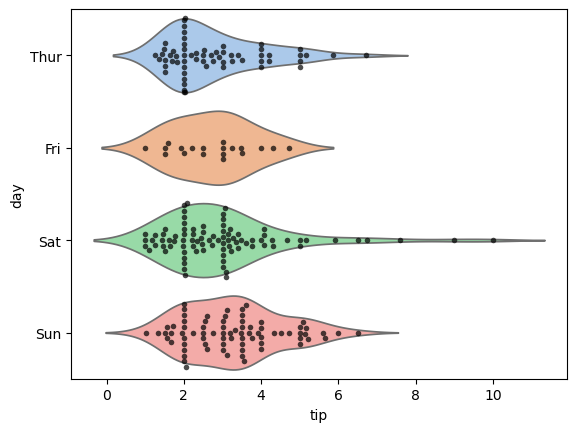

In [16]:
sns.violinplot(data=df, x='tip', y='day', palette='pastel', inner=None)
sns.swarmplot(data=df, x='tip', y='day', color='black', size=4, alpha=0.7)
plt.show()